In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────
customers = pd.read_csv("customers.csv")
products  = pd.read_csv("products.csv")
sales     = pd.read_csv("sales.csv")

# ── Apply Week 1 Cleaning ──────────────────────────────────
customers['Date_of_Birth']     = pd.to_datetime(customers['Date_of_Birth'])
customers['Registration_Date'] = pd.to_datetime(customers['Registration_Date'])
sales['Order_Date']            = pd.to_datetime(sales['Order_Date'])
sales['Delivery_Date']         = pd.to_datetime(sales['Delivery_Date'])
sales['Coupon_Code']           = sales['Coupon_Code'].fillna('No Coupon')
sales['Has_Review']            = sales['Rating'].notna().astype(int)
sales                          = sales[sales['Total_Amount'] >= 0]

# ── Shared Plot Style ──────────────────────────────────────
plt.rcParams.update({
    'font.family':  'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     15,
    'figure.dpi':        150,
})

print("✅ Data loaded and cleaned.")
print(f"   Customers : {customers.shape}")
print(f"   Products  : {products.shape}")
print(f"   Sales     : {sales.shape}")

✅ Data loaded and cleaned.
   Customers : (40000, 15)
   Products  : (2000, 12)
   Sales     : (249995, 22)


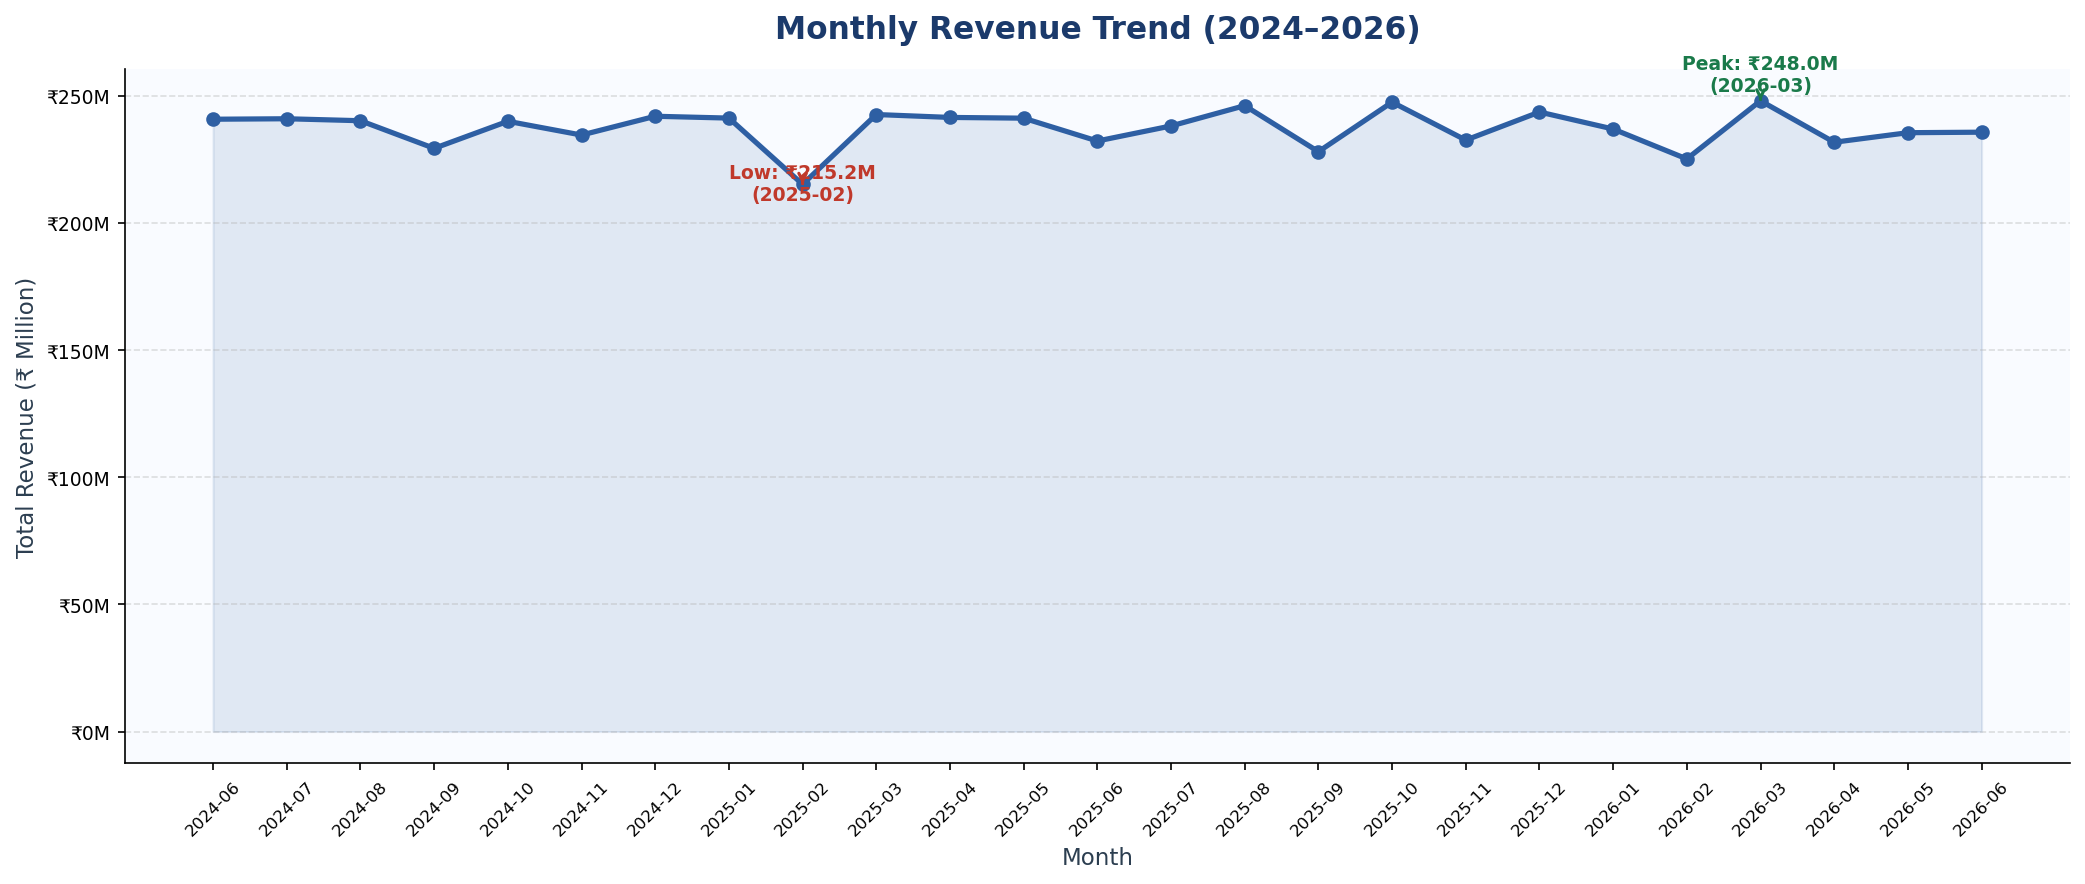

✅ Viz 1 saved.


In [3]:
# ── VISUALIZATION 1: Monthly Revenue Trend (Annotated Line Chart) ──

sales['Month'] = sales['Order_Date'].dt.to_period('M')
monthly_revenue = sales.groupby('Month')['Total_Amount'].sum().reset_index()
monthly_revenue['Month_str'] = monthly_revenue['Month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot line
ax.plot(monthly_revenue['Month_str'], monthly_revenue['Total_Amount'] / 1e6,
        color='#2E5FA3', linewidth=2.5, marker='o', markersize=6, zorder=3)

# Shade under line
ax.fill_between(monthly_revenue['Month_str'],
                monthly_revenue['Total_Amount'] / 1e6,
                alpha=0.12, color='#2E5FA3')

# Find peak and lowest months
peak_idx = monthly_revenue['Total_Amount'].idxmax()
low_idx  = monthly_revenue['Total_Amount'].idxmin()

peak_x = monthly_revenue.loc[peak_idx, 'Month_str']
peak_y = monthly_revenue.loc[peak_idx, 'Total_Amount'] / 1e6

low_x  = monthly_revenue.loc[low_idx, 'Month_str']
low_y  = monthly_revenue.loc[low_idx, 'Total_Amount'] / 1e6

# Annotate peak
ax.annotate(f'Peak: ₹{peak_y:.1f}M\n({peak_x})',
            xy=(peak_x, peak_y),
            xytext=(peak_x, peak_y + 4),
            ha='center', fontsize=9, color='#1A7A4A', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1A7A4A', lw=1.5))

# Annotate lowest
ax.annotate(f'Low: ₹{low_y:.1f}M\n({low_x})',
            xy=(low_x, low_y),
            xytext=(low_x, low_y - 6),
            ha='center', fontsize=9, color='#C0392B', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))

# Formatting
ax.set_title('Monthly Revenue Trend (2024–2026)', fontsize=15, fontweight='bold', color='#1B3A6B')
ax.set_xlabel('Month', fontsize=11, color='#2C3E50')
ax.set_ylabel('Total Revenue (₹ Million)', fontsize=11, color='#2C3E50')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0fM'))
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#F9FBFF')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('viz1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz 1 saved.")

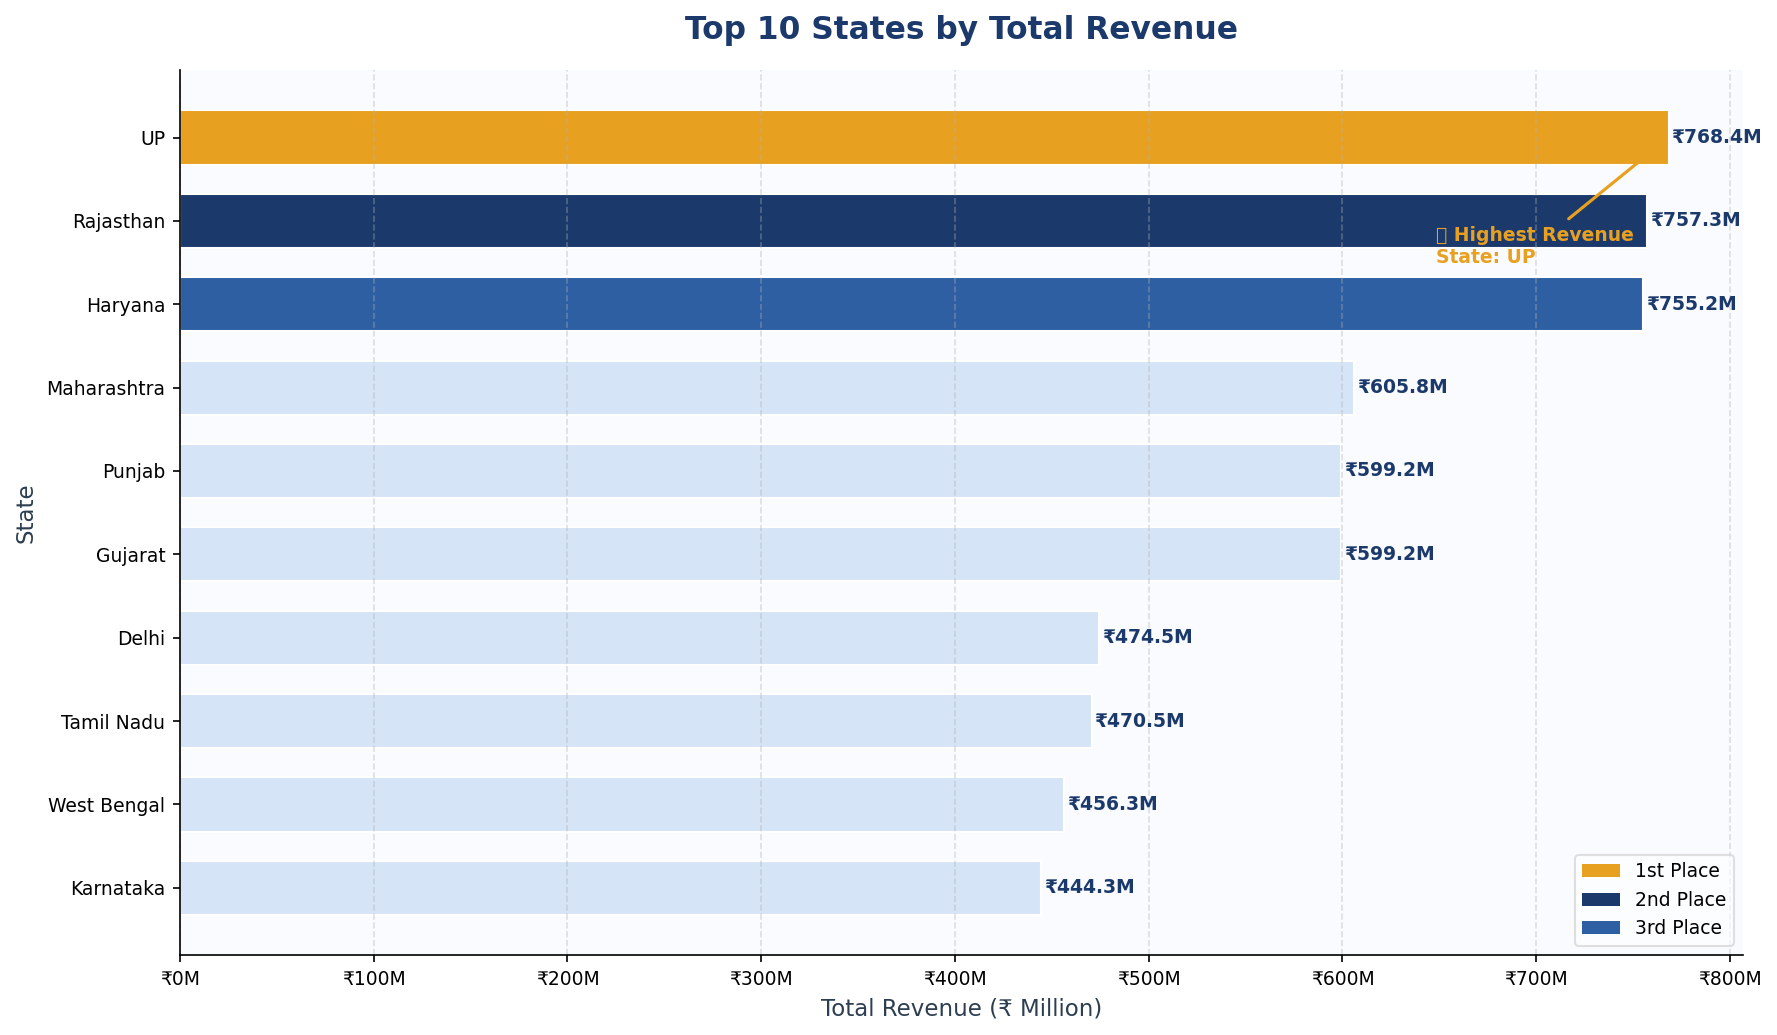

✅ Viz 2 saved.


In [4]:
# ── VISUALIZATION 2: Top 10 States by Revenue ──

state_revenue = (sales.groupby('State')['Total_Amount']
                 .sum()
                 .sort_values(ascending=True)
                 .tail(10))

colors = ['#D6E4F7'] * 7 + ['#2E5FA3', '#1B3A6B', '#E8A020']

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(state_revenue.index, state_revenue.values / 1e6,
               color=colors, edgecolor='white', height=0.65)

# Add value labels at end of each bar
for bar, val in zip(bars, state_revenue.values / 1e6):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f'₹{val:.1f}M', va='center', ha='left',
            fontsize=9, color='#1B3A6B', fontweight='bold')

# Annotate top state
top_state = state_revenue.index[-1]
top_val   = state_revenue.values[-1] / 1e6
ax.annotate(f'🏆 Highest Revenue\nState: {top_state}',
            xy=(top_val, 9),
            xytext=(top_val - 120, 7.5),
            fontsize=9, color='#E8A020', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E8A020', lw=1.5))

# Formatting
ax.set_title('Top 10 States by Total Revenue', fontsize=15,
             fontweight='bold', color='#1B3A6B')
ax.set_xlabel('Total Revenue (₹ Million)', fontsize=11, color='#2C3E50')
ax.set_ylabel('State', fontsize=11, color='#2C3E50')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0fM'))
ax.tick_params(axis='both', labelsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_facecolor('#F9FBFF')
fig.patch.set_facecolor('white')

# Legend for top 3
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8A020', label='1st Place'),
    Patch(facecolor='#1B3A6B', label='2nd Place'),
    Patch(facecolor='#2E5FA3', label='3rd Place'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          framealpha=0.6)

plt.tight_layout()
plt.savefig('viz2_state_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz 2 saved.")

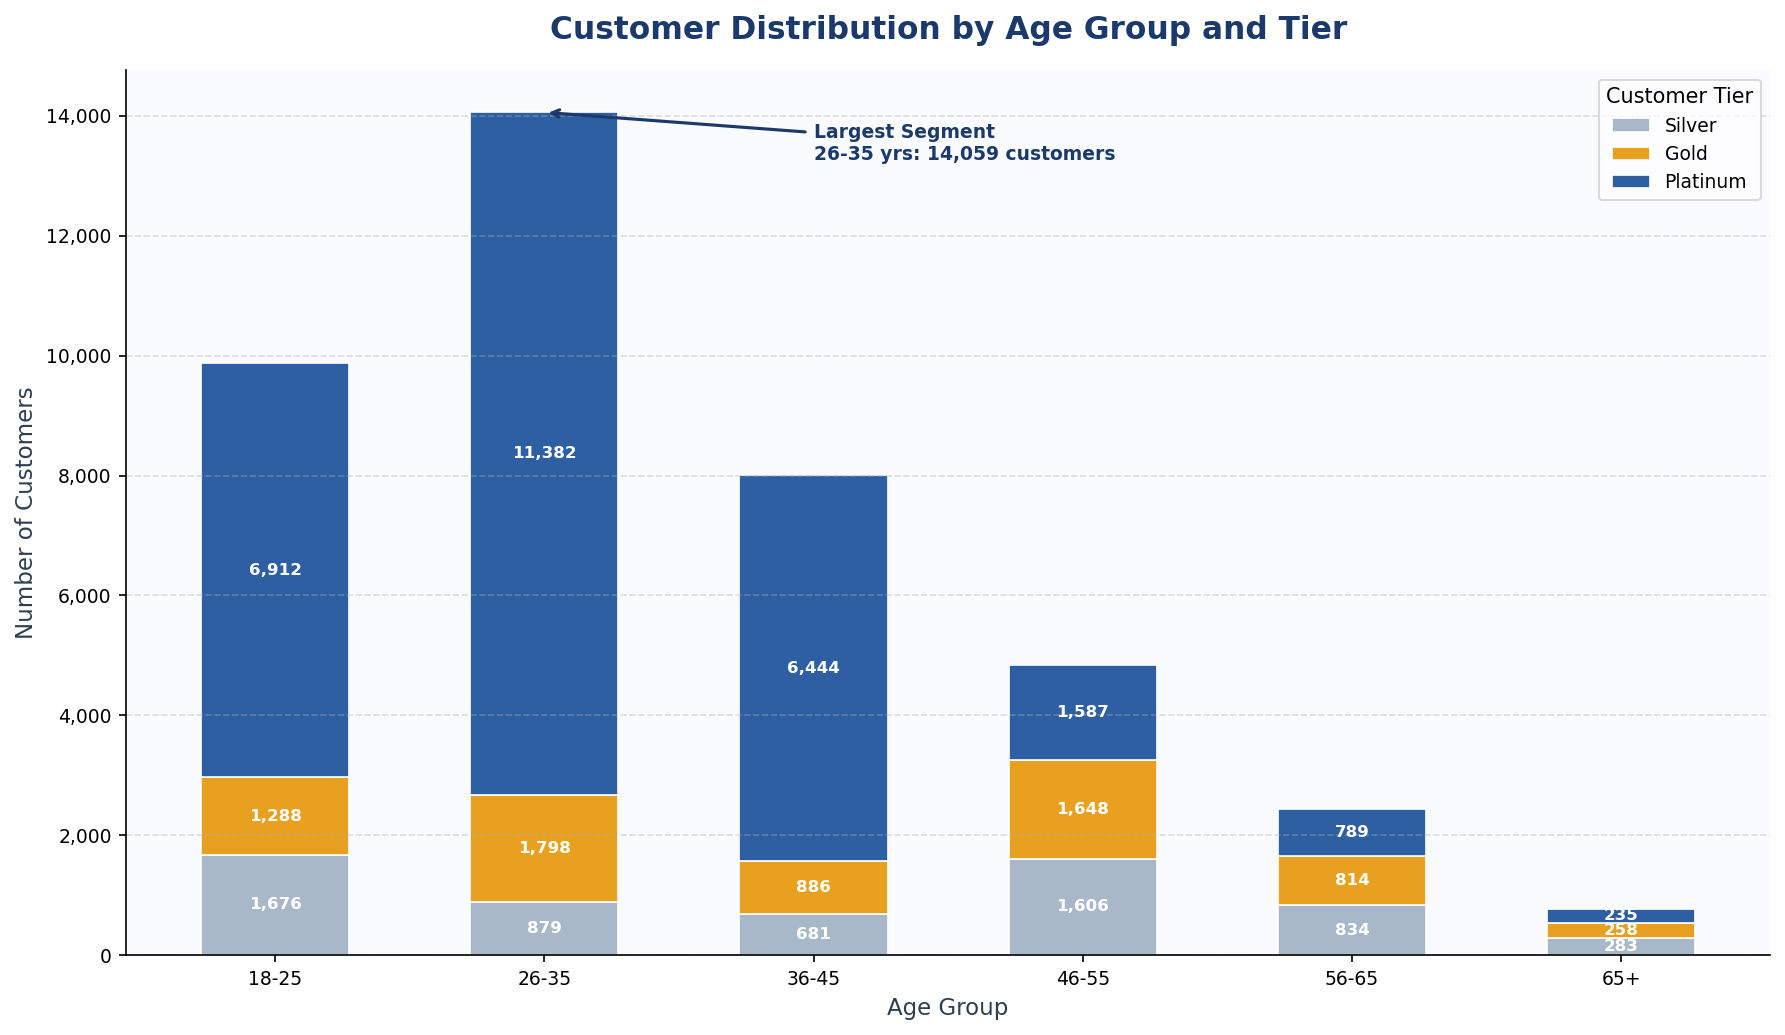

✅ Viz 3 saved.


In [5]:
# ── VISUALIZATION 3: Customer Age Group by Customer Tier ──

age_tier = (customers.groupby(['Age_Group', 'Customer_Tier'])
            .size()
            .unstack(fill_value=0))

# Reorder age groups logically
age_order = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
age_tier  = age_tier.reindex([a for a in age_order if a in age_tier.index])

tier_colors = {
    'Silver':   '#A8B8C8',
    'Gold':     '#E8A020',
    'Platinum': '#2E5FA3',
}

fig, ax = plt.subplots(figsize=(12, 7))

bottom = pd.Series([0] * len(age_tier), index=age_tier.index)

for tier in ['Silver', 'Gold', 'Platinum']:
    if tier in age_tier.columns:
        bars = ax.bar(age_tier.index, age_tier[tier],
                      bottom=bottom,
                      label=tier,
                      color=tier_colors[tier],
                      edgecolor='white',
                      linewidth=0.8,
                      width=0.55)
        # Add value labels inside bars
        for bar, val in zip(bars, age_tier[tier]):
            if val > 200:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f'{val:,}', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += age_tier[tier]

# Annotate dominant group
dominant_group = age_tier.sum(axis=1).idxmax()
dominant_val   = age_tier.sum(axis=1).max()
ax.annotate(f'Largest Segment\n{dominant_group} yrs: {dominant_val:,} customers',
            xy=(dominant_group, dominant_val),
            xytext=(2, dominant_val - 800),
            fontsize=9, color='#1B3A6B', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1B3A6B', lw=1.5))

# Formatting
ax.set_title('Customer Distribution by Age Group and Tier',
             fontsize=15, fontweight='bold', color='#1B3A6B')
ax.set_xlabel('Age Group', fontsize=11, color='#2C3E50')
ax.set_ylabel('Number of Customers', fontsize=11, color='#2C3E50')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='both', labelsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#F9FBFF')
fig.patch.set_facecolor('white')
ax.legend(title='Customer Tier', fontsize=9, title_fontsize=10,
          loc='upper right', framealpha=0.7)

plt.tight_layout()
plt.savefig('viz3_age_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz 3 saved.")

In [7]:
import subprocess
subprocess.run(['pip', 'install', 'squarify'], capture_output=True)
print("✅ squarify installed")

✅ squarify installed


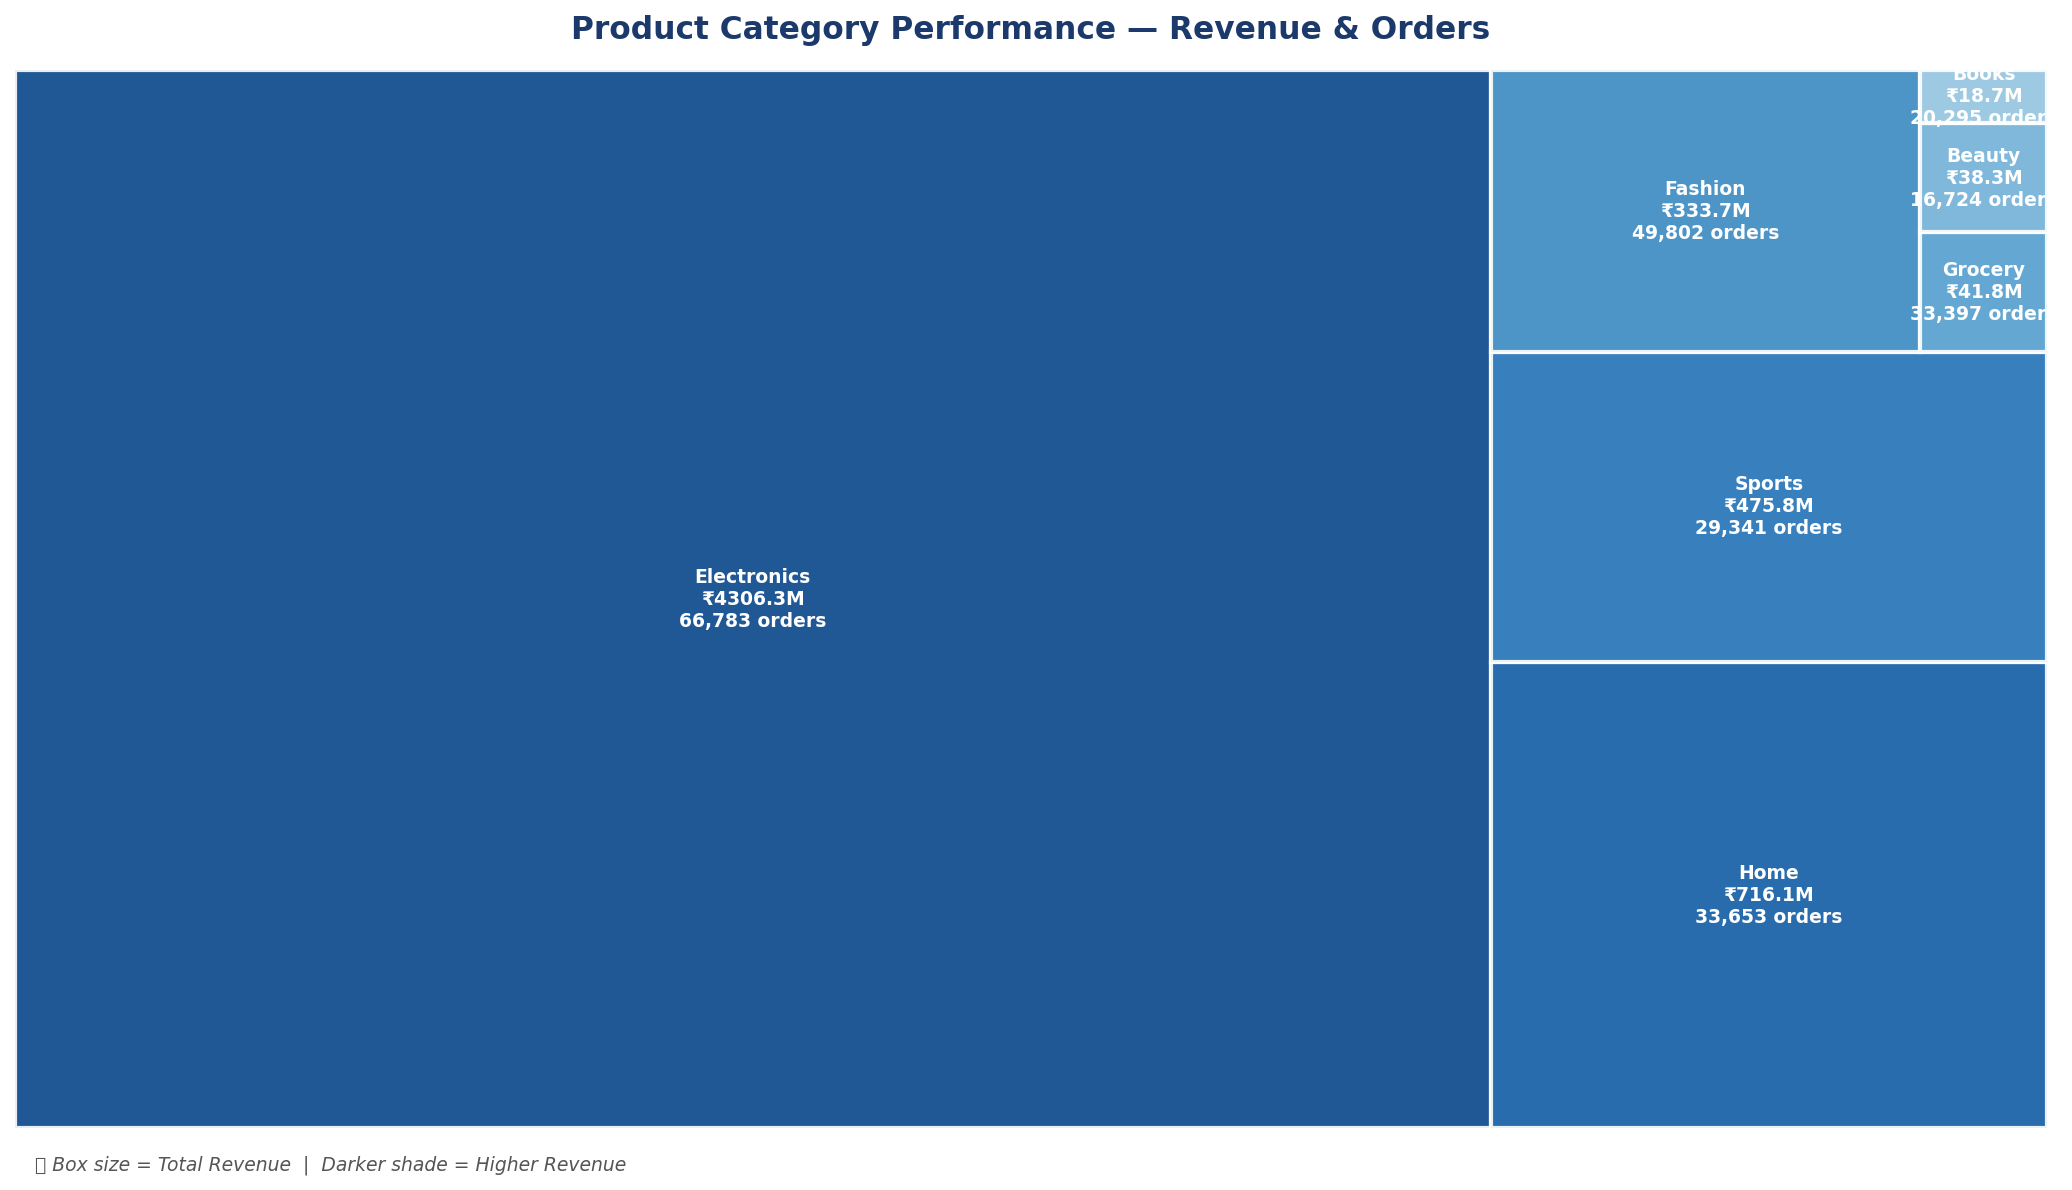

✅ Viz 4 saved.


In [8]:
# ── VISUALIZATION 4: Product Category Performance (Treemap) ──

import squarify

# Merge sales with products to get category
sales_products = sales.merge(products[['Product_ID', 'Category']], 
                              on='Product_ID', how='left')

category_stats = (sales_products.groupby('Category')
                  .agg(
                      Total_Revenue=('Total_Amount', 'sum'),
                      Total_Orders=('Order_ID', 'count'),
                      Avg_Order_Value=('Total_Amount', 'mean')
                  )
                  .sort_values('Total_Revenue', ascending=False)
                  .reset_index())

# Normalize for treemap
sizes  = category_stats['Total_Revenue'].values
labels = [
    f"{row['Category']}\n₹{row['Total_Revenue']/1e6:.1f}M\n{row['Total_Orders']:,} orders"
    for _, row in category_stats.iterrows()
]

# Color palette — darker = higher revenue
palette = plt.cm.Blues(
    [0.4 + 0.6 * (i / len(sizes)) for i in range(len(sizes))]
)
colors = list(reversed(palette))

fig, ax = plt.subplots(figsize=(14, 8))

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.9,
    edgecolor='white',
    linewidth=2,
    text_kwargs={'fontsize': 9, 'color': 'white', 'fontweight': 'bold'},
    ax=ax
)

ax.set_title('Product Category Performance — Revenue & Orders',
             fontsize=15, fontweight='bold', color='#1B3A6B', pad=15)
ax.axis('off')
fig.patch.set_facecolor('white')

# Add legend for interpretation
ax.text(0.01, -0.04,
        '📦 Box size = Total Revenue  |  Darker shade = Higher Revenue',
        transform=ax.transAxes,
        fontsize=9, color='#555555', style='italic')

plt.tight_layout()
plt.savefig('viz4_category_treemap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz 4 saved.")

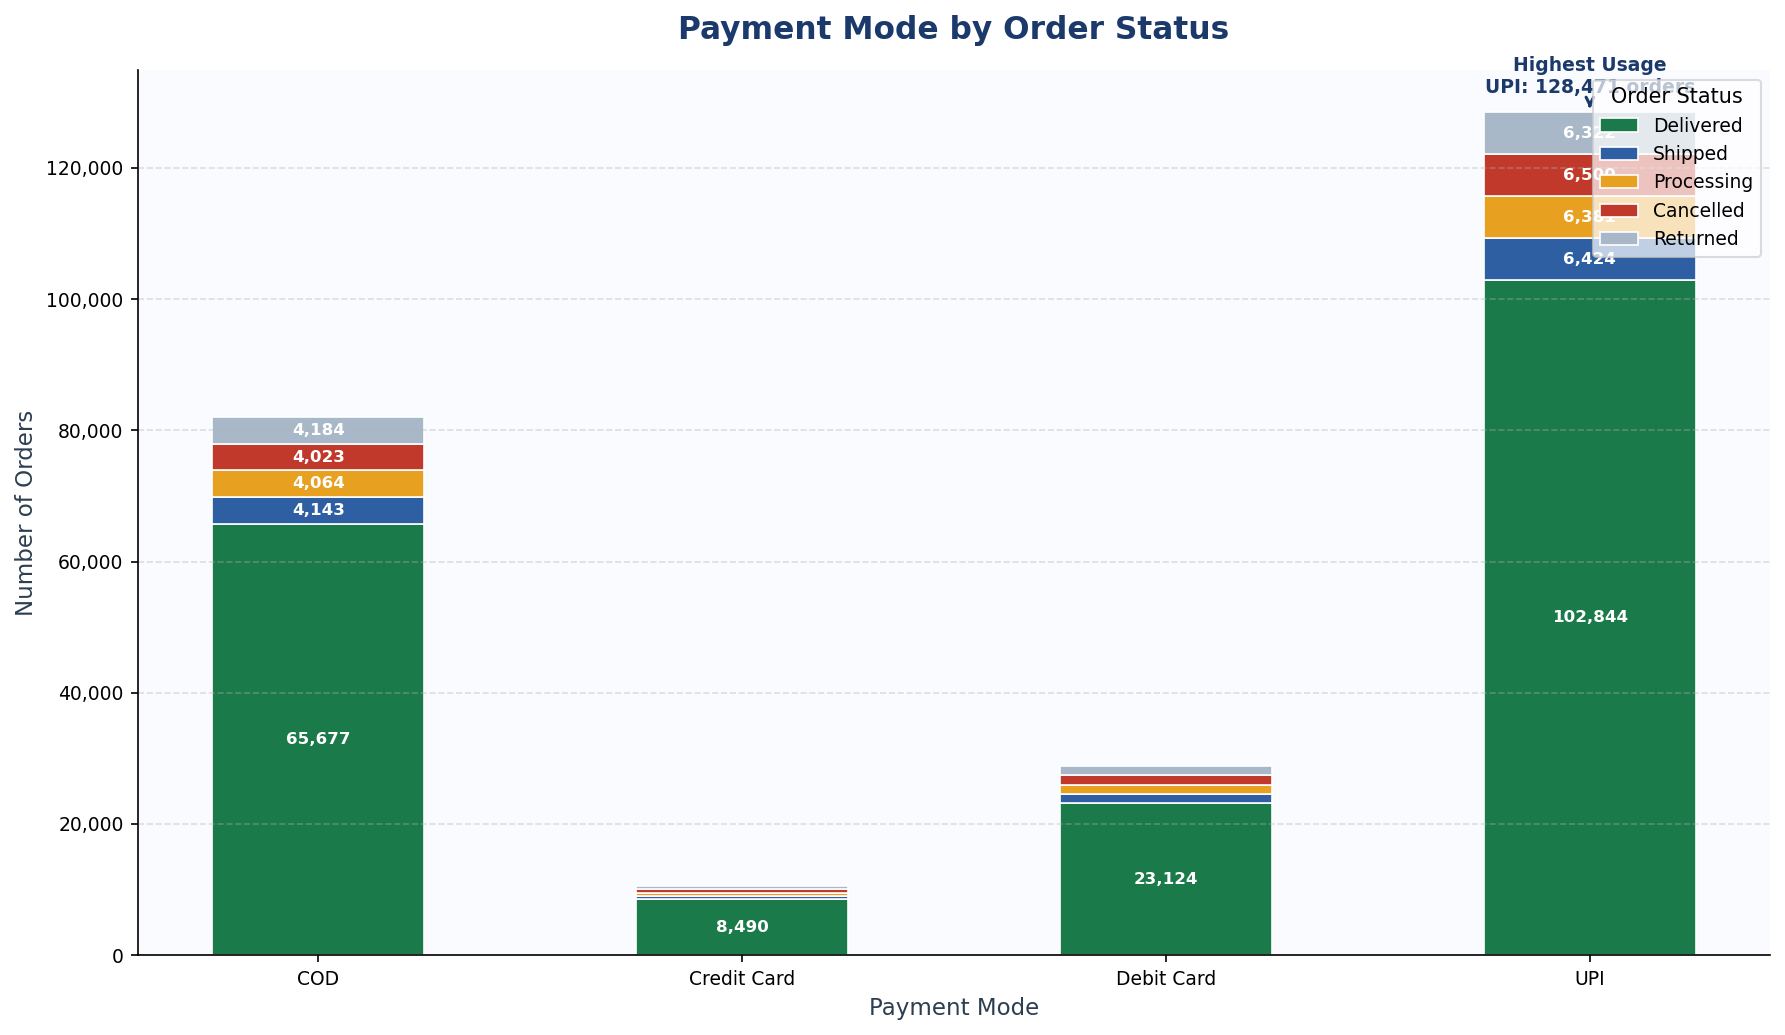

✅ Viz 5 saved.


In [11]:
# ── VISUALIZATION 5: Payment Mode by Order Status ──

payment_status = (sales.groupby(['Payment_Mode', 'Order_Status'])
                  .size()
                  .unstack(fill_value=0))

# Reorder columns logically
col_order = ['Delivered', 'Shipped', 'Processing', 'Cancelled', 'Returned']
payment_status = payment_status[[c for c in col_order if c in payment_status.columns]]

status_colors = {
    'Delivered':  '#1A7A4A',
    'Shipped':    '#2E5FA3',
    'Processing': '#E8A020',
    'Cancelled':  '#C0392B',
    'Returned':   '#A8B8C8',
}

fig, ax = plt.subplots(figsize=(12, 7))

bottom = pd.Series([0] * len(payment_status), index=payment_status.index)

for status in col_order:
    if status in payment_status.columns:
        bars = ax.bar(payment_status.index,
                      payment_status[status],
                      bottom=bottom,
                      label=status,
                      color=status_colors[status],
                      edgecolor='white',
                      linewidth=0.8,
                      width=0.5)
        # Add value labels inside bars
        for bar, val in zip(bars, payment_status[status]):
            if val > 1500:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f'{val:,}',
                        ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += payment_status[status]

# Annotate UPI as dominant
upi_total = payment_status.loc['UPI'].sum() if 'UPI' in payment_status.index else 0
ax.annotate(f'Highest Usage\nUPI: {upi_total:,} orders',
            xy=('UPI', upi_total),
            xytext=('UPI', upi_total + 3000),
            ha='center', fontsize=9,
            color='#1B3A6B', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1B3A6B', lw=1.5))

# Formatting
ax.set_title('Payment Mode by Order Status',
             fontsize=15, fontweight='bold', color='#1B3A6B')
ax.set_xlabel('Payment Mode', fontsize=11, color='#2C3E50')
ax.set_ylabel('Number of Orders', fontsize=11, color='#2C3E50')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='both', labelsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#F9FBFF')
fig.patch.set_facecolor('white')
ax.legend(title='Order Status', fontsize=9, title_fontsize=10,
          loc='upper right', framealpha=0.7)

plt.tight_layout()
plt.savefig('viz5_payment_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz 5 saved.")

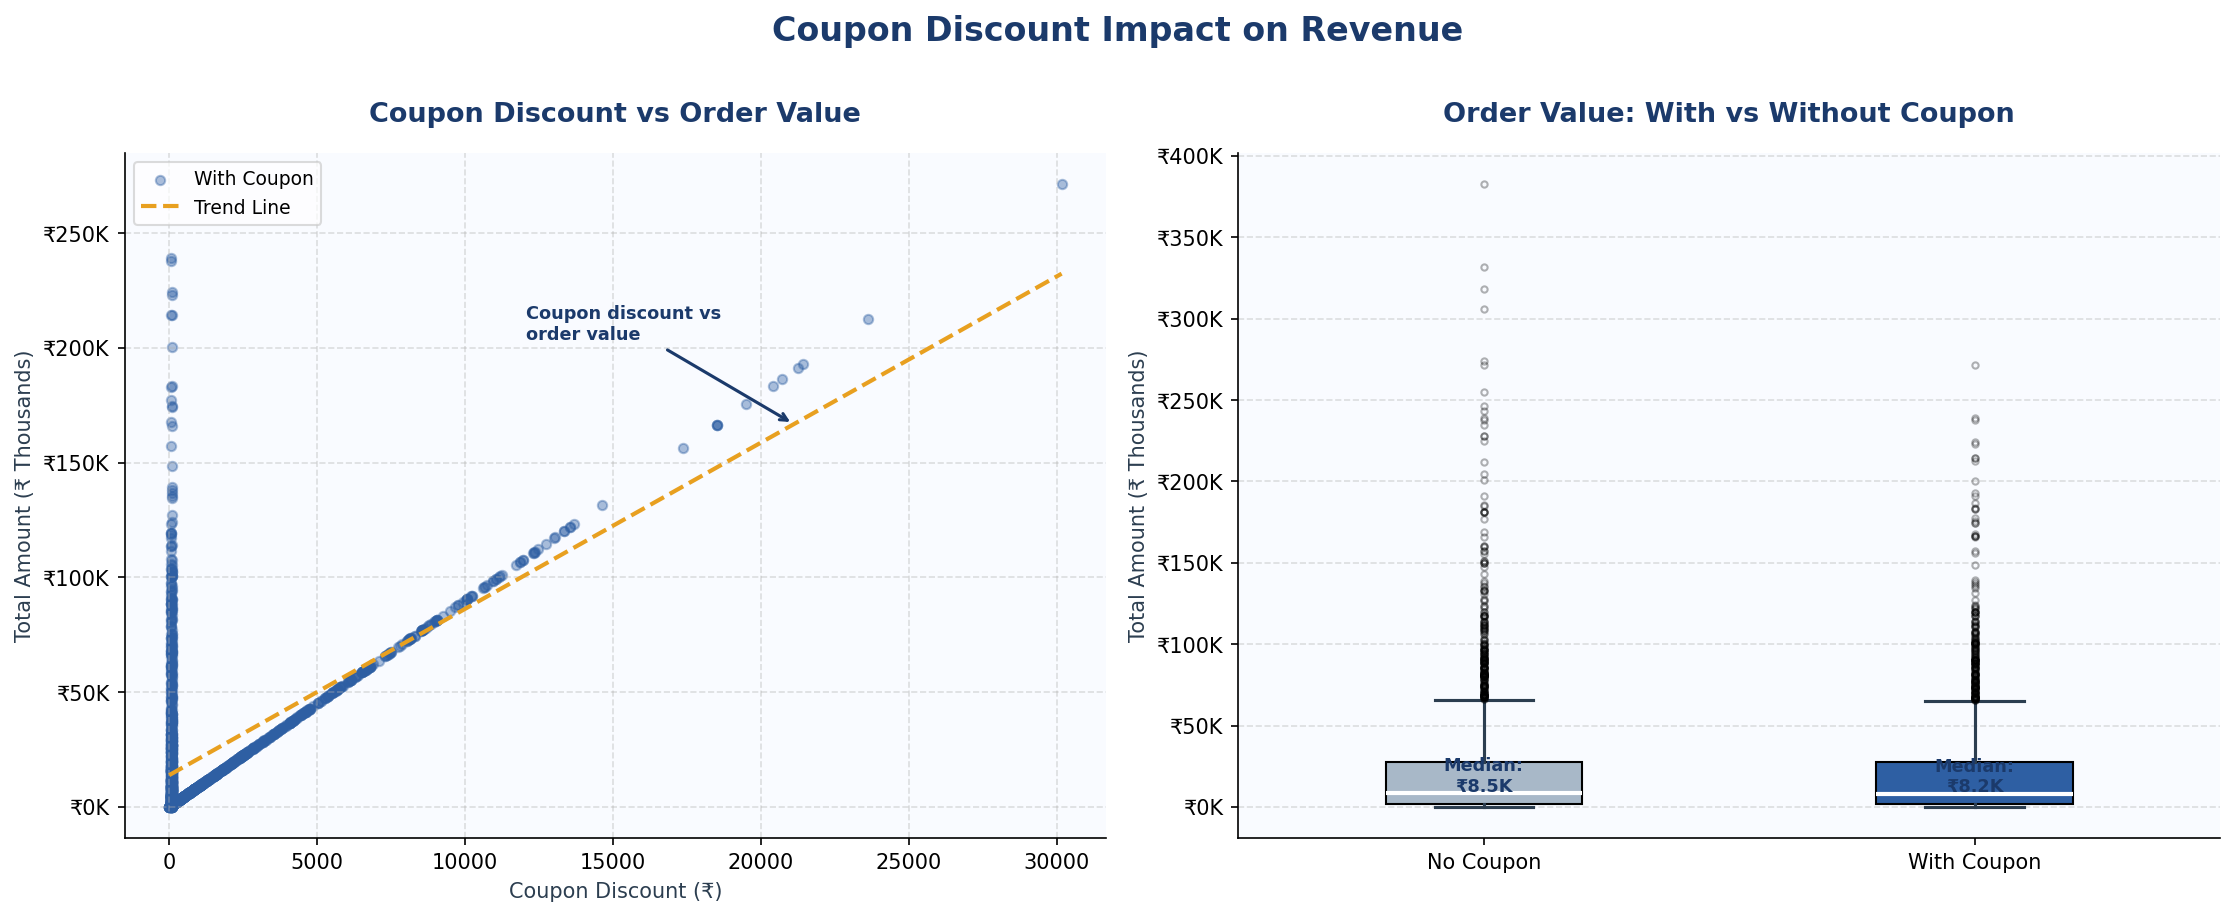

✅ Viz 6 saved.


In [15]:
# ── VISUALIZATION 6: Coupon Discount Impact on Revenue ──

# Filter only orders where coupon was used
coupon_used = sales[sales['Coupon_Code'] != 'No Coupon'].copy()
no_coupon   = sales[sales['Coupon_Code'] == 'No Coupon'].copy()

# Sample for performance (scatter with 250k points is slow)
coupon_sample    = coupon_used.sample(n=2000, random_state=42)
no_coupon_sample = no_coupon.sample(n=2000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: Scatter — Discount vs Total Amount ──
ax1 = axes[0]
ax1.scatter(coupon_sample['Coupon_Discount'],
            coupon_sample['Total_Amount'] / 1000,
            alpha=0.4, color='#2E5FA3', s=20, label='With Coupon')

# Trend line
import numpy as np
z = np.polyfit(coupon_sample['Coupon_Discount'],
               coupon_sample['Total_Amount'] / 1000, 1)
p = np.poly1d(z)
x_line = np.linspace(coupon_sample['Coupon_Discount'].min(),
                     coupon_sample['Coupon_Discount'].max(), 100)
ax1.plot(x_line, p(x_line), color='#E8A020',
         linewidth=2, linestyle='--', label='Trend Line')

ax1.annotate('Coupon discount vs\norder value',
             xy=(coupon_sample['Coupon_Discount'].max() * 0.7,
                 p(coupon_sample['Coupon_Discount'].max() * 0.7)),
             xytext=(coupon_sample['Coupon_Discount'].max() * 0.4,
                     coupon_sample['Total_Amount'].max() / 1000 * 0.75),
             fontsize=8.5, color='#1B3A6B', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#1B3A6B', lw=1.5))

ax1.set_title('Coupon Discount vs Order Value',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax1.set_xlabel('Coupon Discount (₹)', fontsize=10, color='#2C3E50')
ax1.set_ylabel('Total Amount (₹ Thousands)', fontsize=10, color='#2C3E50')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0fK'))
ax1.grid(linestyle='--', alpha=0.4)
ax1.set_facecolor('#F9FBFF')
ax1.legend(fontsize=9, framealpha=0.7)

# ── Right: Box Plot — Order Value with vs without Coupon ──
ax2 = axes[1]

data_to_plot = [
    no_coupon_sample['Total_Amount'] / 1000,
    coupon_sample['Total_Amount'] / 1000
]

bp = ax2.boxplot(data_to_plot,
                 patch_artist=True,
                 widths=0.4,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#2C3E50', linewidth=1.5),
                 capprops=dict(color='#2C3E50', linewidth=1.5),
                 flierprops=dict(marker='o', color='#A8B8C8',
                                 alpha=0.3, markersize=3))

bp['boxes'][0].set_facecolor('#A8B8C8')
bp['boxes'][1].set_facecolor('#2E5FA3')

# Median annotations
for i, dataset in enumerate(data_to_plot):
    median_val = dataset.median()
    ax2.text(i + 1, median_val + 1,
             f'Median:\n₹{median_val:.1f}K',
             ha='center', fontsize=8.5,
             color='#1B3A6B', fontweight='bold')

ax2.set_title('Order Value: With vs Without Coupon',
              fontsize=13, fontweight='bold', color='#1B3A6B')
ax2.set_ylabel('Total Amount (₹ Thousands)', fontsize=10, color='#2C3E50')
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['No Coupon', 'With Coupon'], fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0fK'))
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_facecolor('#F9FBFF')

fig.suptitle('Coupon Discount Impact on Revenue',
             fontsize=16, fontweight='bold', color='#1B3A6B', y=1.01)
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('viz6_coupon_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz 6 saved.")

In [14]:
# ── INSIGHTS SUMMARY ──────────────────────────────────────
print("=" * 55)
print("WEEK 2 — KEY INSIGHTS SUMMARY")
print("=" * 55)

# Viz 1 — Monthly Revenue
monthly = sales.groupby('Month')['Total_Amount'].sum()
print(f"\n1. MONTHLY REVENUE:")
print(f"   Peak  : {monthly.idxmax()} → ₹{monthly.max()/1e6:.2f}M")
print(f"   Low   : {monthly.idxmin()} → ₹{monthly.min()/1e6:.2f}M")
print(f"   Growth: ₹{(monthly.max()-monthly.min())/1e6:.2f}M difference")

# Viz 2 — State Revenue
state_rev = sales.groupby('State')['Total_Amount'].sum().sort_values(ascending=False)
print(f"\n2. TOP 3 STATES BY REVENUE:")
for state, val in state_rev.head(3).items():
    print(f"   {state:15} → ₹{val/1e6:.2f}M")

# Viz 3 — Age & Tier
age_counts = customers['Age_Group'].value_counts()
tier_counts = customers['Customer_Tier'].value_counts()
print(f"\n3. CUSTOMER SEGMENTS:")
print(f"   Top Age Group : {age_counts.idxmax()} ({age_counts.max():,} customers)")
print(f"   Top Tier      : {tier_counts.idxmax()} ({tier_counts.max():,} customers)")

# Viz 4 — Category
sales_products = sales.merge(products[['Product_ID','Category']], on='Product_ID', how='left')
cat_rev = sales_products.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False)
print(f"\n4. TOP 3 PRODUCT CATEGORIES:")
for cat, val in cat_rev.head(3).items():
    print(f"   {cat:20} → ₹{val/1e6:.2f}M")

# Viz 5 — Payment Mode
pay_counts = sales['Payment_Mode'].value_counts()
print(f"\n5. PAYMENT MODE:")
for mode, count in pay_counts.items():
    print(f"   {mode:15} → {count:,} orders ({count/len(sales)*100:.1f}%)")

# Viz 6 — Coupon Impact
coupon_avg    = sales[sales['Coupon_Code'] != 'No Coupon']['Total_Amount'].median()
no_coupon_avg = sales[sales['Coupon_Code'] == 'No Coupon']['Total_Amount'].median()
print(f"\n6. COUPON IMPACT:")
print(f"   Median order WITH coupon    → ₹{coupon_avg:,.2f}")
print(f"   Median order WITHOUT coupon → ₹{no_coupon_avg:,.2f}")
print(f"   Difference                  → ₹{coupon_avg - no_coupon_avg:,.2f}")

print("\n" + "=" * 55)

WEEK 2 — KEY INSIGHTS SUMMARY

1. MONTHLY REVENUE:
   Peak  : 2026-03 → ₹248.03M
   Low   : 2025-02 → ₹215.19M
   Growth: ₹32.84M difference

2. TOP 3 STATES BY REVENUE:
   UP              → ₹768.35M
   Rajasthan       → ₹757.29M
   Haryana         → ₹755.22M

3. CUSTOMER SEGMENTS:
   Top Age Group : 26-35 (14,059 customers)
   Top Tier      : Platinum (27,349 customers)

4. TOP 3 PRODUCT CATEGORIES:
   Electronics          → ₹4306.35M
   Home                 → ₹716.13M
   Sports               → ₹475.84M

5. PAYMENT MODE:
   UPI             → 128,471 orders (51.4%)
   COD             → 82,091 orders (32.8%)
   Debit Card      → 28,856 orders (11.5%)
   Credit Card     → 10,577 orders (4.2%)

6. COUPON IMPACT:
   Median order WITH coupon    → ₹8,145.81
   Median order WITHOUT coupon → ₹8,354.44
   Difference                  → ₹-208.63

